In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    r"C:\Users\Arumu\Downloads\customer_dataset.csv"
)

df.head()

,CustomerID,Age,MonthlyCharges,Tenure,ContractType,InternetService,SupportCalls,Churn
0,1000,28,45,18,Two-Year,DSL,6,1
1,1001,43,33,14,Monthly,Cable,6,0
2,1002,21,23,49,Yearly,Cable,2,0
3,1003,63,50,10,Monthly,Cable,10,1
4,1004,43,138,5,Monthly,Cable,3,1


In [4]:
print(df.shape)

df.info()

df.describe()

(500, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       500 non-null    int64 
 1   Age              500 non-null    int64 
 2   MonthlyCharges   500 non-null    int64 
 3   Tenure           500 non-null    int64 
 4   ContractType     500 non-null    object
 5   InternetService  500 non-null    object
 6   SupportCalls     500 non-null    int64 
 7   Churn            500 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 31.4+ KB


,CustomerID,Age,MonthlyCharges,Tenure,SupportCalls,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1249.500000,45.178000,84.784000,34.096000,4.810000,0.302000
std,144.481833,15.690337,38.869822,20.675535,3.120477,0.459585
min,1000.000000,18.000000,20.000000,0.000000,0.000000,0.000000
25%,1124.750000,32.000000,50.000000,16.000000,2.000000,0.000000
50%,1249.500000,45.000000,84.000000,33.000000,5.000000,0.000000
75%,1374.250000,58.250000,120.250000,51.000000,7.000000,1.000000
max,1499.000000,70.000000,150.000000,72.000000,10.000000,1.000000


In [5]:
print(df.isnull().sum())

CustomerID         0
Age                0
MonthlyCharges     0
Tenure             0
ContractType       0
InternetService    0
SupportCalls       0
Churn              0
dtype: int64


In [6]:
le = LabelEncoder()

df['ContractType'] = le.fit_transform(df['ContractType'])

df['InternetService'] = le.fit_transform(df['InternetService'])

In [7]:
X = df.drop(
    columns=['CustomerID','Churn']
)

y = df['Churn']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [10]:
print("LOGISTIC REGRESSION")

print("Accuracy:",
      accuracy_score(y_test,y_pred_lr))

print("Precision:",
      precision_score(y_test,y_pred_lr))

print("Recall:",
      recall_score(y_test,y_pred_lr))

print("F1:",
      f1_score(y_test,y_pred_lr))

print("ROC AUC:",
      roc_auc_score(y_test,y_prob_lr))

LOGISTIC REGRESSION
Accuracy: 0.77
Precision: 0.6666666666666666
Recall: 0.16
F1: 0.25806451612903225
ROC AUC: 0.7669333333333332


In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [12]:
print("RANDOM FOREST")

print("Accuracy:",
      accuracy_score(y_test,y_pred_rf))

print("Precision:",
      precision_score(y_test,y_pred_rf))

print("Recall:",
      recall_score(y_test,y_pred_rf))

print("F1:",
      f1_score(y_test,y_pred_rf))

print("ROC AUC:",
      roc_auc_score(y_test,y_prob_rf))

RANDOM FOREST
Accuracy: 0.73
Precision: 0.4166666666666667
Recall: 0.2
F1: 0.2702702702702703
ROC AUC: 0.7338666666666667


In [13]:
lr_cv = cross_val_score(
    lr,
    X,
    y,
    cv=5
)

rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Logistic Regression CV Mean:",
      lr_cv.mean())

print("Random Forest CV Mean:",
      rf_cv.mean())

Logistic Regression CV Mean: 0.734
Random Forest CV Mean: 0.716


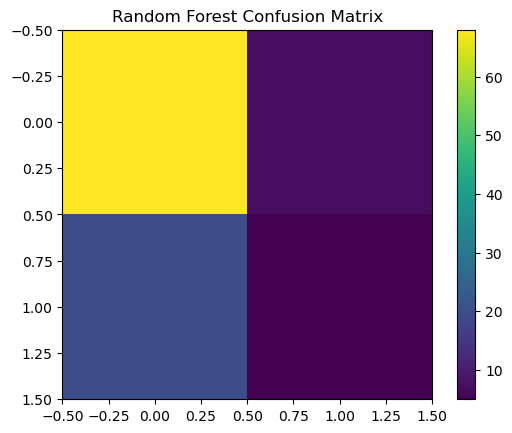

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.show()

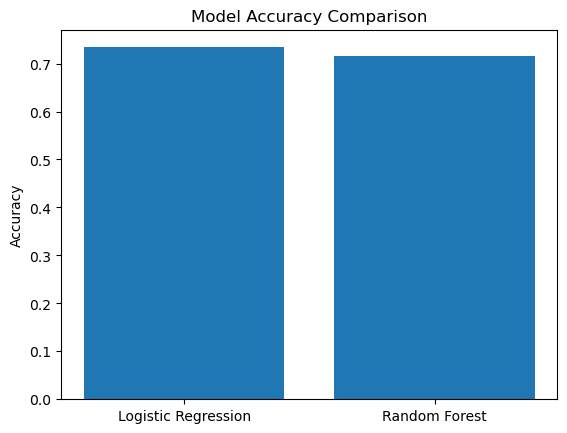

In [16]:
models = [
    'Logistic Regression',
    'Random Forest'
]

accuracy = [
    0.734,
    0.716
]

plt.bar(models,accuracy)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

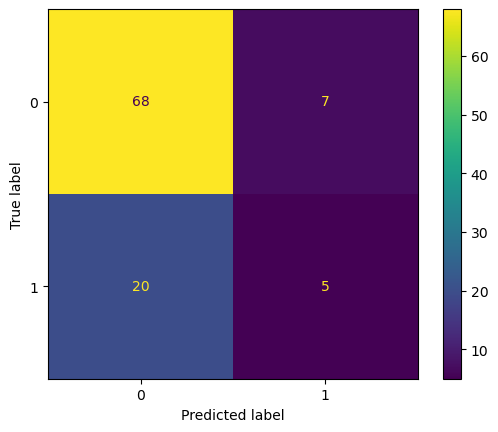

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()

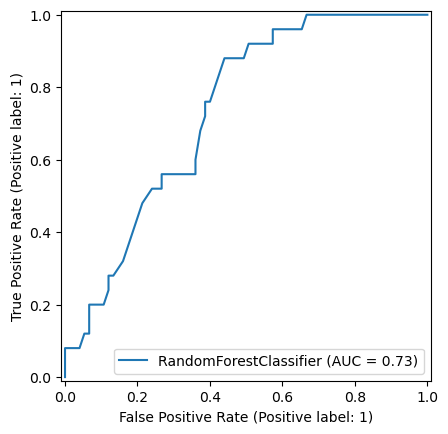

In [18]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()